In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import time
import gget

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc

import cupy as cp
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator

from cuml.manifold.umap import simplicial_set_embedding
from scanpy.tools._utils import get_init_pos_from_paga 
from cuml.manifold.umap import find_ab_params

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

sc.settings.verbosity = 3

# Gene Data

In [2]:
%%time
fpath = "../../resources/gene_names.tsv.gz"
gdf = pd.read_csv(fpath, sep='\t', low_memory=False)
print(f"{gdf.shape=}")

protein_coding = gdf[gdf['Gene type'] == 'protein_coding']['Gene name'].unique()
print(f"N protein coding: {protein_coding.shape=}")

gdf.shape=(73466, 8)
N protein coding: protein_coding.shape=(18149,)
CPU times: user 128 ms, sys: 23.9 ms, total: 152 ms
Wall time: 152 ms


# Load data

In [3]:
%%time
# --- paths ---------------------------------------------------------------
datas = {
    "bone_marrow": "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/bone_marrow_processed.h5ad",
    "fibroblasts": "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/processed.h5ad",
}

# --- load each dataset ---------------------------------------------------
adatas = []
for name, path in datas.items():
    a = sc.read_h5ad(path)
    a.obs["dataset"] = name      # track origin
    adatas.append(a)

# ------------------------------------------------------------------------
# OPTION 1 (preferred): anndata.concat  → union of genes + all obs columns
# ------------------------------------------------------------------------
adata = an.concat(
    adatas,
    axis=0,              # stack cells
    join="outer",        # keep every gene (union)
    merge="first",       # keep all obs columns; fill missing values with NaN
    label="source",      # new obs column with dataset name
    keys=list(datas),    # used by label and index_unique
    index_unique="-"     # make cell barcodes unique (adds "-dataset" suffix)
)
adata

CPU times: user 9.53 s, sys: 6.77 s, total: 16.3 s
Wall time: 22.9 s


AnnData object with n_obs × n_vars = 21475 × 25739
    obs: 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'leiden', 'bm_cluster', 'dataset', 'phase', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str', 'source'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    obsm: 'X_pca', 'X_umap', 'X_pca_harmony', 'X_umap_

# Metadata clean up

In [4]:
labels = {
    'C1' : "reprogram",
    'C2' : "reprogram",
    'C3' : "reprogram",
    'C4' : "control",
    'C5' : "control",
}

adata.obs['hsc_label'] = adata.obs['cluster_str'].map(labels)
adata.obs['label'] = np.where(adata.obs['bm_cluster'].notna(), 'bone marrow', adata.obs['hsc_label'])

adata.obs['cluster'] = np.where(adata.obs['cluster_str'].notna(), adata.obs['cluster_str'], adata.obs['bm_cluster'])
adata.obs['library'] = np.where(adata.obs['batch'].notna(), adata.obs['batch'], adata.obs['source'])


print(adata.obs['library'].value_counts().to_string())
print()
print(adata.obs['label'].value_counts().to_string())
print()

keep = ['cluster', 'library', 'label']
columns_to_drop = [x for x in adata.obs.columns if not x in keep]
adata.obs = adata.obs.drop(columns=columns_to_drop)
adata

library
hsc            8326
fib            7541
bone_marrow    5608

label
control        9122
reprogram      6745
bone marrow    5608



AnnData object with n_obs × n_vars = 21475 × 25739
    obs: 'label', 'cluster', 'library'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    obsm: 'X_pca', 'X_umap', 'X_pca_harmony', 'X_umap_bbknn', 'X_umap_harmony', 'X_umap_raw'
    varm: 'PCs'
    layers: 'log_norm', 'raw_counts'

In [5]:
# label_map = {
#     'B1' : 'HSC',
#     'B2' : 'bone marrow',
#     'B3' : 'HSC',
#     'B4' : 'bone marrow',
#     'B5' : 'bone marrow',
#     'B6' : 'HSC',
#     'B7' : 'bone marrow',
#     'B8' : 'bone marrow',
#     'B9' : 'bone marrow',
#     'C1' : 'C1',
#     'C2' : 'C2',
#     'C3' : 'C3',
#     'C4' : 'control',
#     'C5' : 'control',
# }

# adata.obs['label'] = adata.obs['cluster'].map(label_map)
# adata.obs['label'].value_counts()

# Gene Filtering

In [6]:
rsc.get.anndata_to_GPU(adata)

adata.var['filter_pass'] = True # set the gene filter

# pt genes only
adata.var['filter_pass'] = np.where(~adata.var.index.isin(protein_coding), False, adata.var['filter_pass'])

# disallow GO cell cycle genes
fpath = "../../resources/human_cell_cycle_genes.csv"
cdf = pd.read_csv(fpath)
adata.var['filter_pass'] = np.where(adata.var.index.isin(cdf['gene_name'].unique()), False, adata.var['filter_pass'])

# disallow Regev cell cycle genes
fpath = "../../resources/regev_lab_cell_cycle_genes.txt"
genes = [x.strip() for x in open(fpath)]
adata.var['filter_pass'] = np.where(adata.var.index.isin(genes), False, adata.var['filter_pass'])

# disallow mitochondrial and ribosomal genes
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('MT'), False, adata.var['filter_pass'])
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('RP'), False, adata.var['filter_pass'])

# finally, in the top variable genes
# rsc.pp.highly_variable_genes(adata, batch_key='library', n_top_genes=3500)
# rsc.pp.highly_variable_genes(adata, n_top_genes=5000)
# adata.var['filter_pass'] = np.where(~adata.var['highly_variable'], False, adata.var['filter_pass'])

print(adata.var['filter_pass'].value_counts().to_string())

filter_pass
True     14528
False    11211


In [7]:
idx = adata.obs.sort_values("library", ascending=False).index
adata = adata[idx].copy()
adata.obs.head()

,label,cluster,library
GGGTAGATCCAAACCA-1-fibroblasts,reprogram,C1,hsc
CTGAATGAGGTTGGAC-1-fibroblasts,reprogram,C1,hsc
CTCTCAGCACGTCTCT-1-fibroblasts,control,C5,hsc
CTCTCAGCACTCGATA-1-fibroblasts,reprogram,C3,hsc
CTCTCAGCAGTAGAAT-1-fibroblasts,reprogram,C3,hsc


# Embedding, ECT

[2025-06-17 09:05:10.073] [CUML] [debug] n_neighbors=15
[2025-06-17 09:05:10.073] [CUML] [debug] Calling knn graph run
[2025-06-17 09:05:10.073] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-06-17 09:05:10.174] [CUML] [debug] Done. Calling remove zeros
running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)
--> added 'pos', the PAGA positions (adata.uns['paga'])


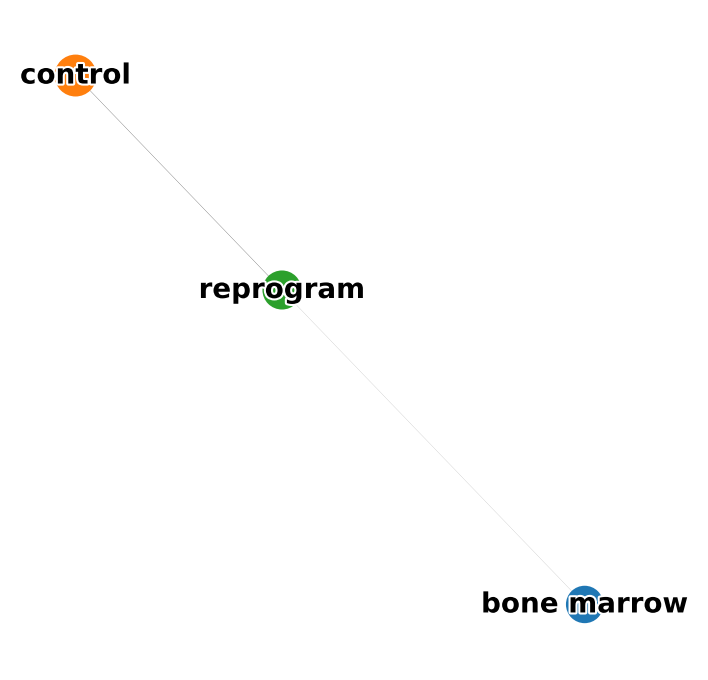

CPU times: user 41.1 s, sys: 7.23 s, total: 48.4 s
Wall time: 49.4 s


In [8]:
%%time
rsc.pp.pca(adata, mask_var='filter_pass')
# rsc.pp.pca(adata, mask_var='highly_variable')
rsc.pp.harmony_integrate(adata, 'library')
rsc.pp.neighbors(adata, n_neighbors=15, use_rep='X_pca_harmony')

sc.tl.paga(adata, groups='label')

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4
sc.pl.paga(
    adata, 
    fontoutline=1.5, 
    edge_width_scale=0.25,  
    frameon=False,          
)

adata.obsm['X_paga'] = get_init_pos_from_paga(adata)

# Custom GPU-bound UMAP using PAGA init

init_pos.shape=(21475, 2) type(init_pos)=<class 'numpy.ndarray'>
data.shape=(21475, 50) type(data)=<class 'numpy.ndarray'>
graph.shape=(21475, 21475) type(graph)=<class 'scipy.sparse._csr.csr_matrix'>
min_dist=1.0 spread=5 a=0.04999630790858062 b=1.0030054314125523
embedding.shape=(21475, 2) type(embedding)=<class 'cuml.internals.array.CumlArray'>


/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/scipy/optimize/_minpack_py.py:539: RuntimeWarning: divide by zero encountered in power
  return func(xdata, *params) - ydata


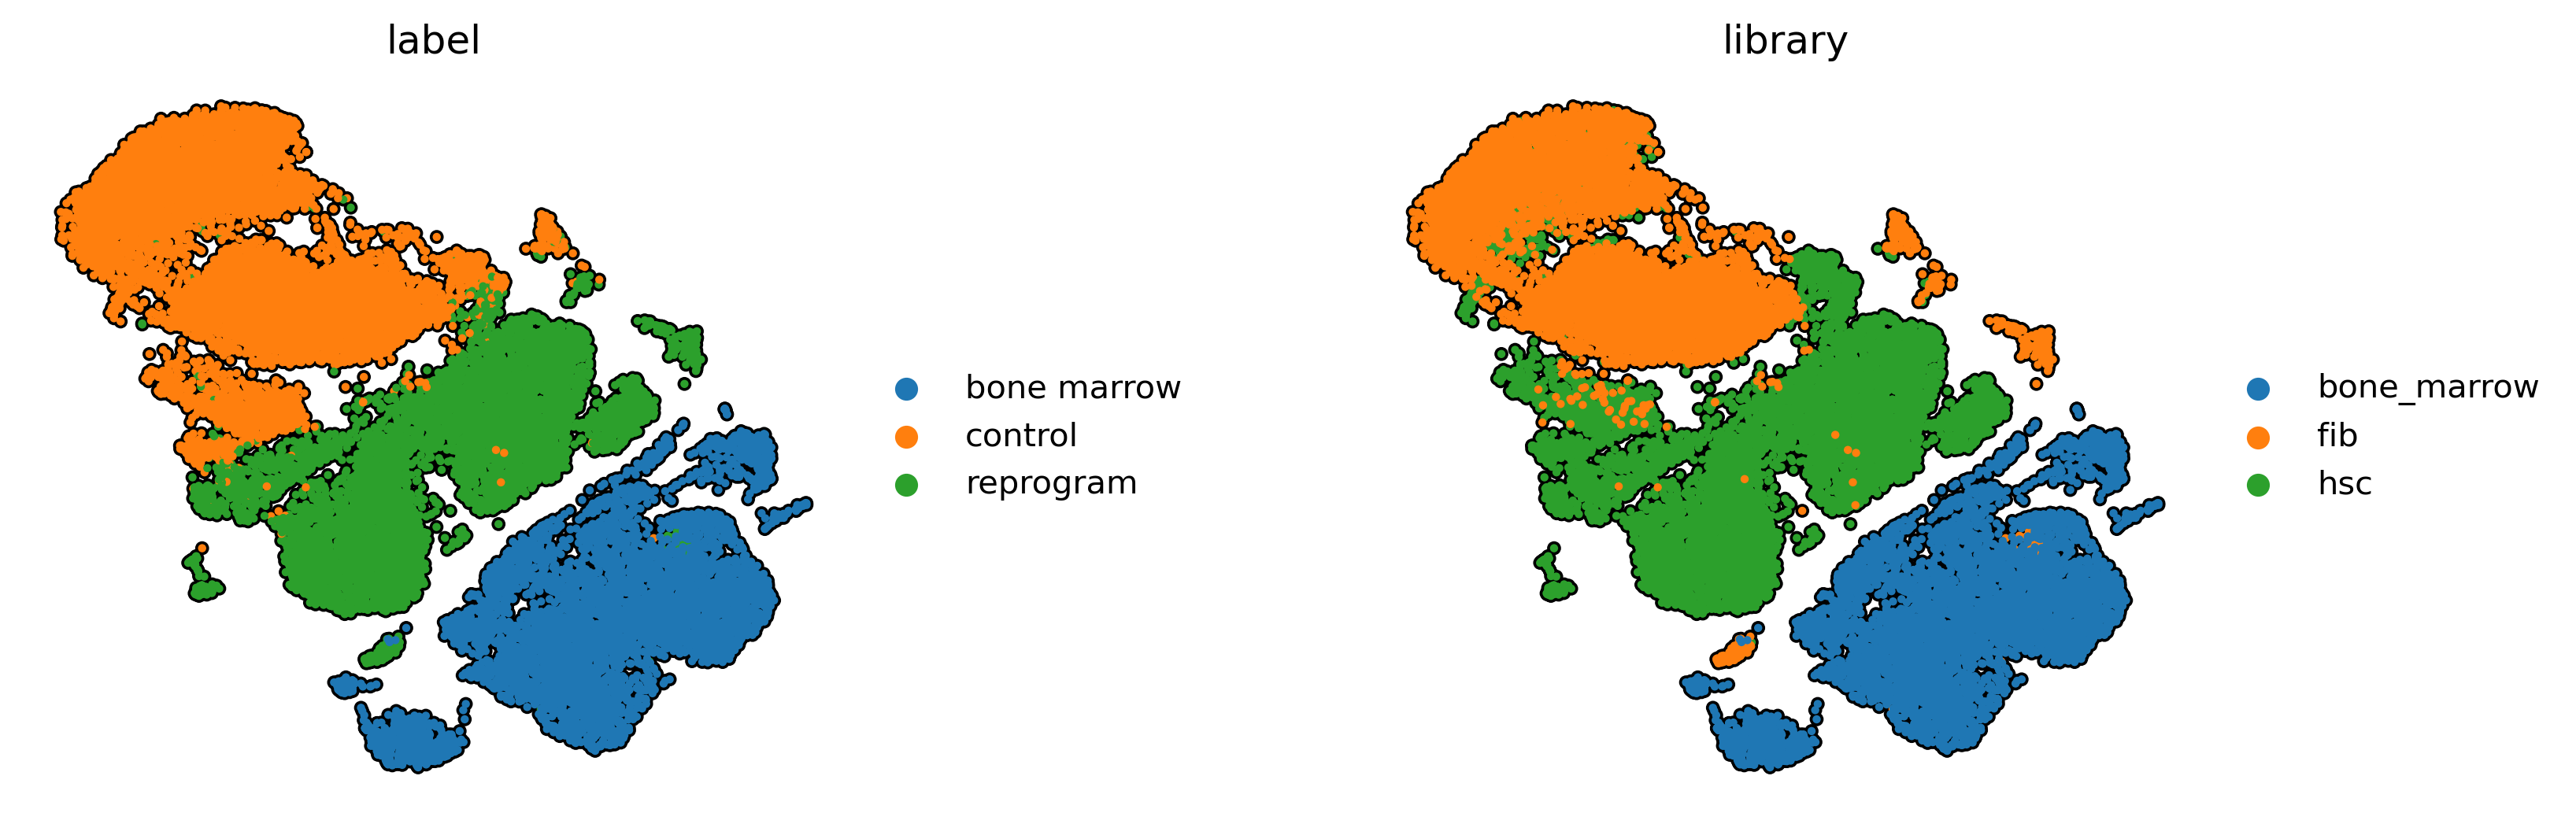

CPU times: user 1.21 s, sys: 35.7 ms, total: 1.25 s
Wall time: 1.25 s


In [9]:
%%time 

min_dist = 1.0
spread = 5

# get the inputs
init_pos = adata.obsm['X_paga']
data = adata.obsm['X_pca_harmony']
graph = adata.obsp['connectivities']

print(f"{init_pos.shape=} {type(init_pos)=}")
print(f"{data.shape=} {type(data)=}")
print(f"{graph.shape=} {type(graph)=}")

# find params
a, b = find_ab_params(spread=spread, min_dist=min_dist)
print(f"{min_dist=} {spread=} {a=} {b=}")

# use simplicial_set_embedding
embedding = simplicial_set_embedding(
    data=data,
    graph=graph,
    a=a, b=b,
    n_components=2,
    init=init_pos,
    random_state=1729,
)

# store embedding
print(f"{embedding.shape=} {type(embedding)=}")
adata.obsm['X_umap'] = embedding.to_device_array().get().copy()

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata, 
    color=['label', 'library'], 
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

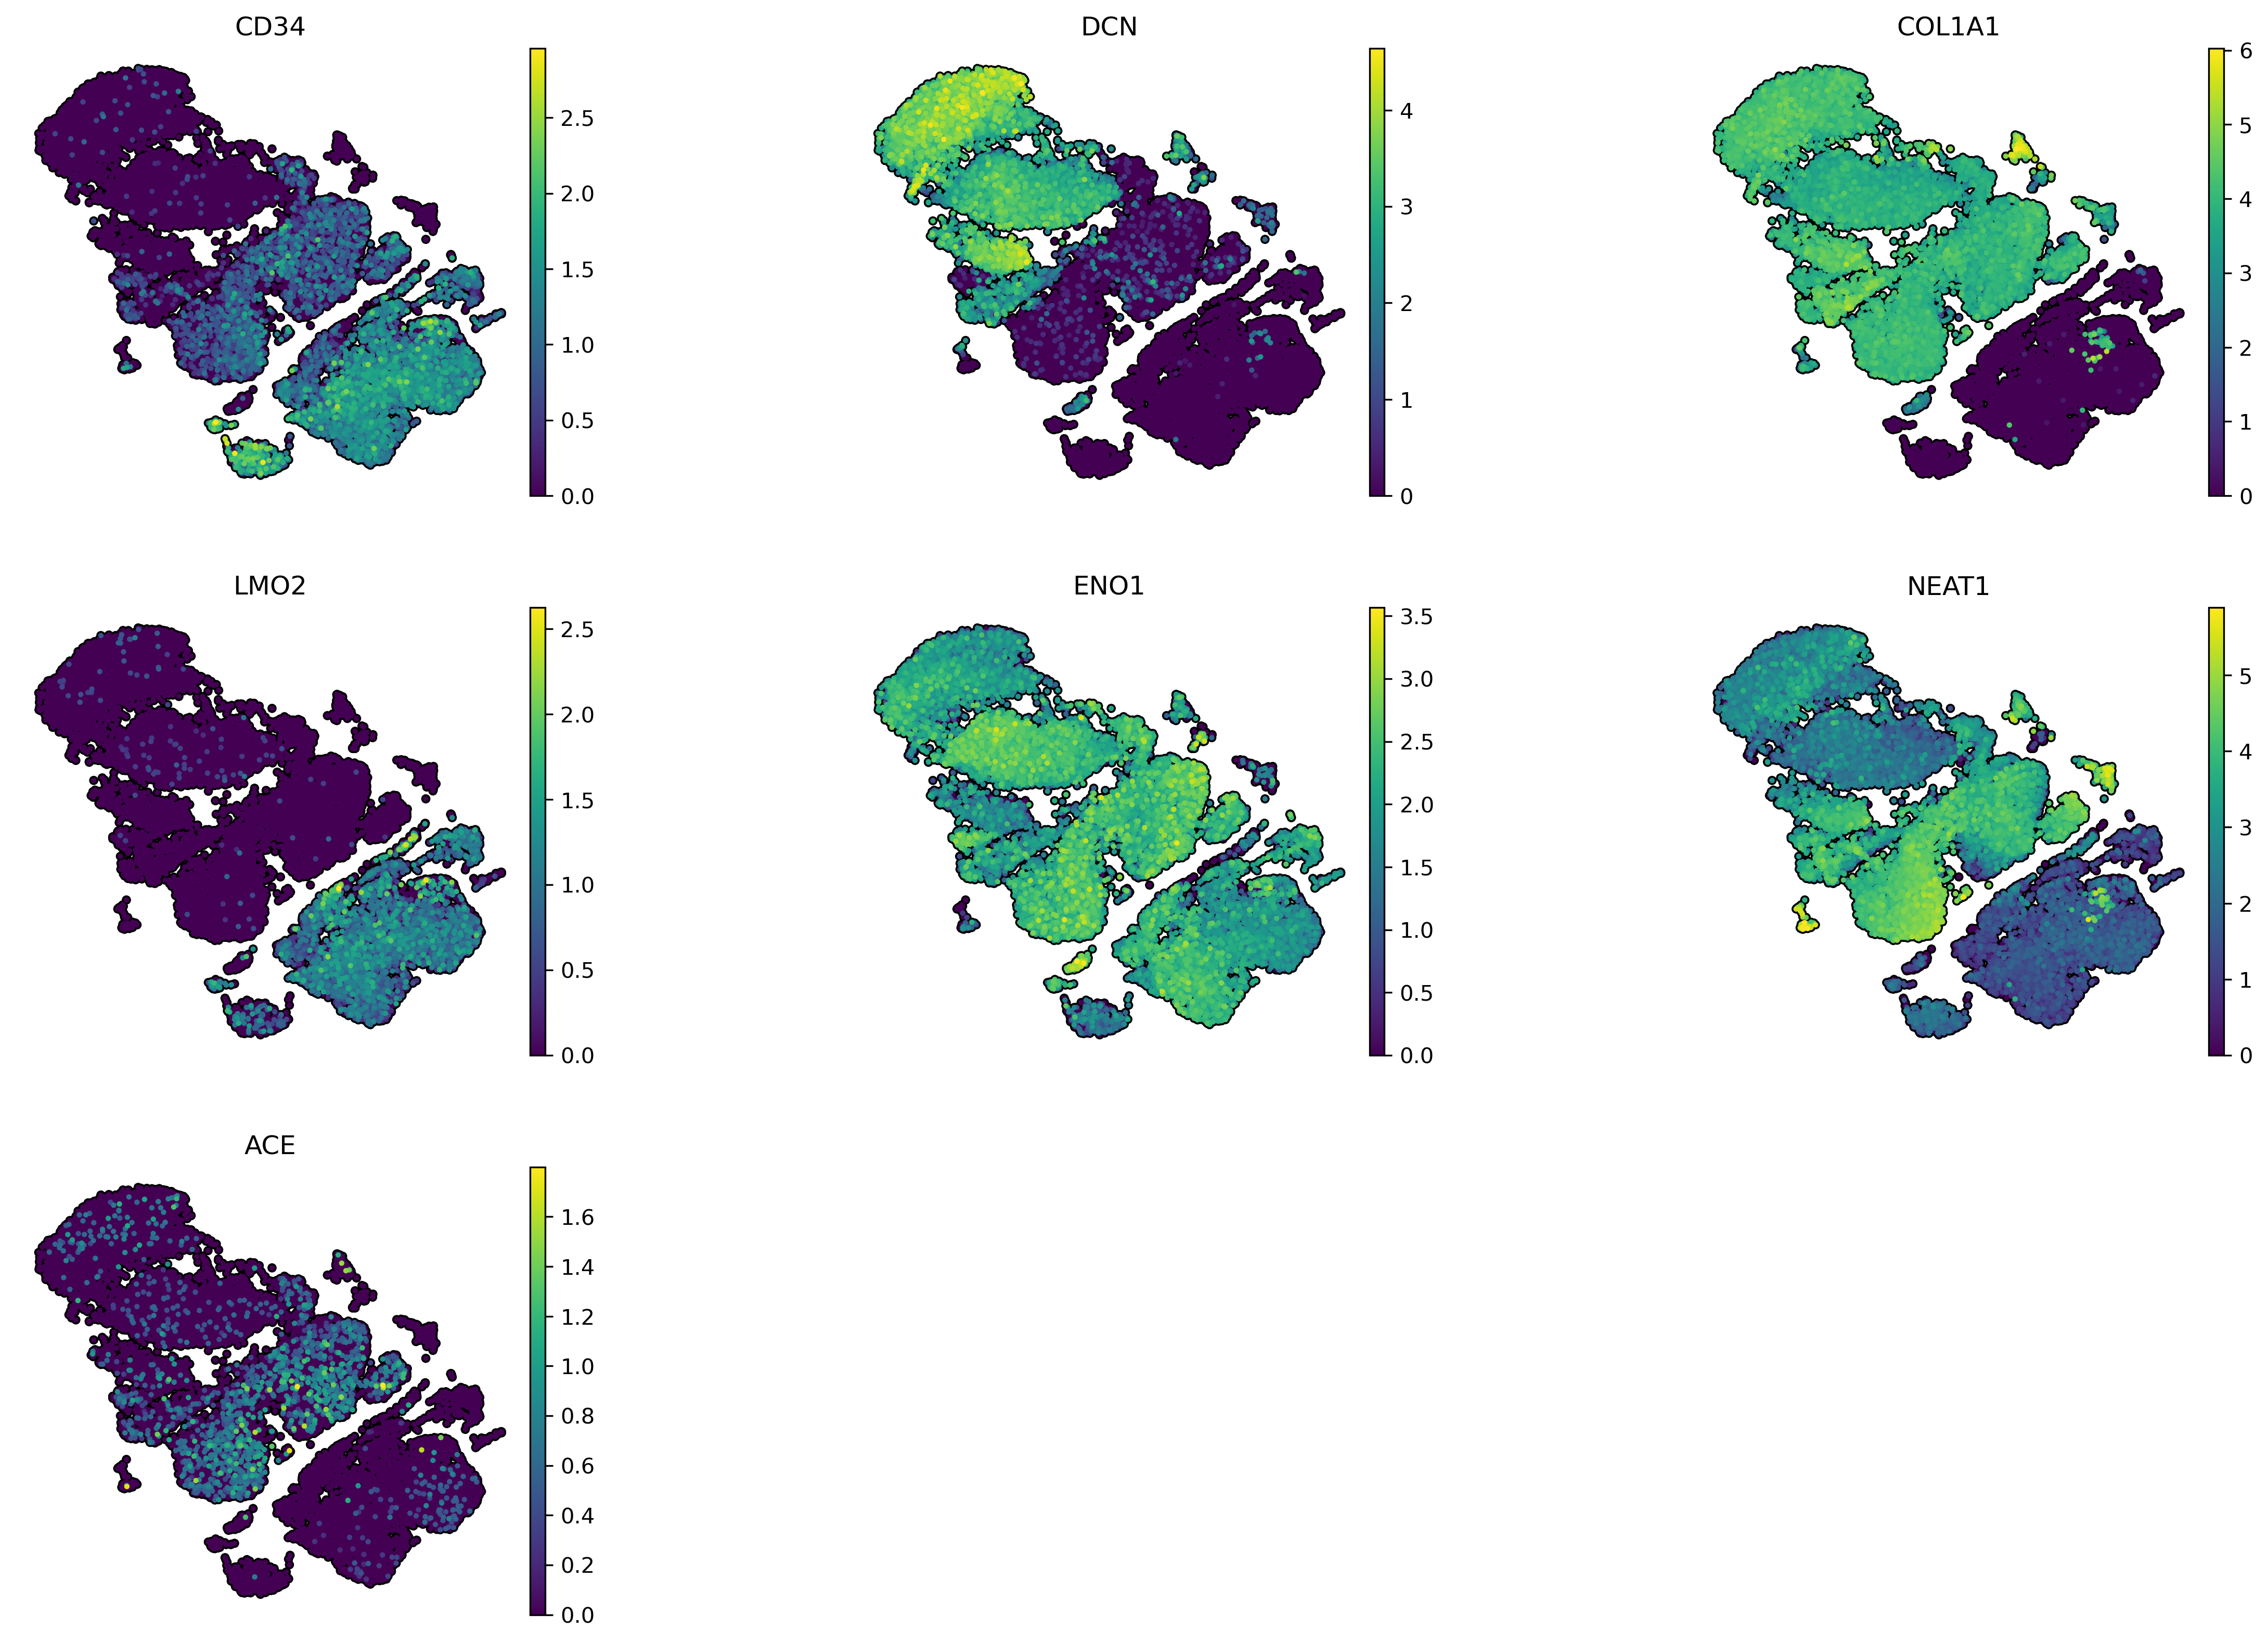

In [10]:
rsc.get.anndata_to_CPU(adata)

sc.pl.umap(
    adata, 
    color=['CD34', 'DCN', 'COL1A1', 'LMO2', "ENO1", 'NEAT1', 'ACE'], 
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

In [11]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
rsc.tl.umap(
    adata,
    random_state=1729
)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata, 
    color=['label', 'library'], 
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

In [ ]:
break

In [ ]:
rsc.tl.draw_graph(adata, init_pos='paga')
# rsc.tl.draw_graph(adata)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    adata, 
    color=['label', 'library'], 
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

In [ ]:
break

In [ ]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

palette = {
    'bone_marrow' : "r", 
    'fib' : 'lightgrey',
    'hsc' : 'deepskyblue', 
}

sc.pl.draw_graph(
    adata, 
    color='library', 
    sort_order=False,
    size=35,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    palette=palette,
    title="",
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

In [ ]:
break